Import Libraries

In [1]:
import sys
from pathlib import Path

# Project root directory
project_root = Path().resolve().parent

# Add project root to Python path
sys.path.append(str(project_root))

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from src.config import RAW_DATA_PATH
from src.data_loader import load_data

Load Dataset

In [3]:
df = load_data(RAW_DATA_PATH)

✅ Dataset loaded successfully.


In [4]:
df.head()
df.shape
df.columns
df.dtypes
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].dt.day_name()
# df.info()
df.shape
df.isnull().sum()
# df["City"].nunique()
df["City"].unique

<bound method Series.unique of 0            Ahmedabad
1            Ahmedabad
2            Ahmedabad
3            Ahmedabad
4            Ahmedabad
             ...      
29526    Visakhapatnam
29527    Visakhapatnam
29528    Visakhapatnam
29529    Visakhapatnam
29530    Visakhapatnam
Name: City, Length: 29531, dtype: str>

# Day 3 - Data Cleaning

## Step 1: Missing Value Analysis

(24850, 16)


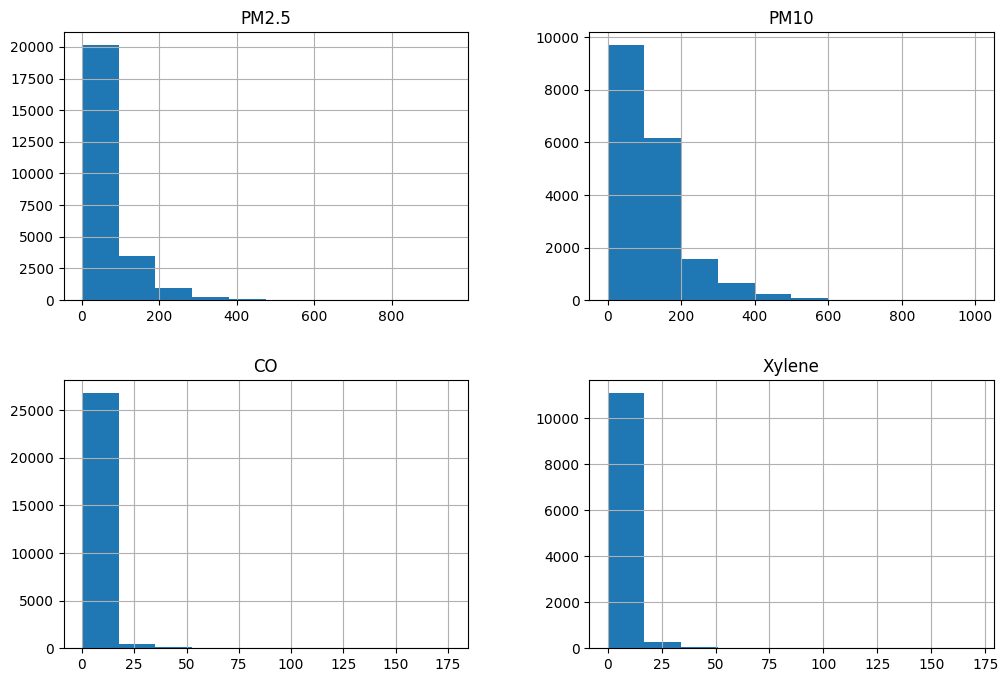

In [ ]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = (
    pd.DataFrame({
        "Missing Values": missing_values,
        "Missing Percentage": missing_percentage
    })
    .sort_values(by="Missing Percentage", ascending=False)
)

missing_df
df[["PM2.5", "PM10", "CO", "Xylene"]].describe().T
df[["PM2.5", "PM10", "CO", "Xylene"]].hist(figsize=(12, 8))



In [ ]:
# Remove rows where target variables are missing
df = df.dropna(subset=["AQI", "AQI_Bucket"])

print("New Shape:", df.shape)

New Shape: (24850, 16)


In [10]:
df.corr(numeric_only=True)["AQI"].sort_values(ascending=False)

AQI        1.000000
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64

Observation:

Xylene has 61.32% missing values, making it the most incomplete feature in the dataset.
It also shows a weak correlation (0.1655) with the target variable (AQI).
Since a large portion of the column would require imputation, it could distort the original feature distribution without providing significant predictive value.
Therefore, Xylene is a suitable candidate for removal.

In [11]:
# drop Xylene column 
df = df.drop(columns=["Xylene"])

print(df.shape)

(24850, 15)


We removed the Xylene feature from the dataset. The number of rows remained the same because only a column was removed. The dataset now contains 24,850 observations and 15 features.

In [12]:
df.isnull().sum()

City             0
Date             0
PM2.5          678
PM10          7086
NO             387
NO2            391
NOx           1857
NH3           6536
CO             445
SO2            605
O3             807
Benzene       3535
Toluene       5826
AQI              0
AQI_Bucket       0
dtype: int64

In [15]:
# Numerical columns with missing values
numerical_columns = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene"
]

# Fill missing values using median
for column in numerical_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)


In [18]:
numerical_columns.append("New_Column")
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

In [ ]:
# Final Preprocessed Dataset
df.to_csv("../data/processed/cleaned_aqi.csv", index=False)

print("✅ Cleaned dataset saved successfully.")



✅ Cleaned dataset saved successfully.


Observation:
PM10 has 37.7% missing values.

Reason:
It has a strong correlation (0.80) with AQI and is an important predictor.

Decision:
Retain the feature and use median imputation because the distribution is right-skewed and contains outliers.